# Train ANN Failure Classifier with PyTorch

In this notebook we train a feed-forward ANN to be able to predict if a cross section fails for a given set of internal forces or not. 

How does good look like? The ideal model 
- generalizes well and scores just as good on unseed data than on the data it is trained on
- has a high NPV score, because the risk is to predict no failure for a cross section that would fail in reality

What we did to achieve these goals:
- Deep network with many hidden layers to make it able to understand complex relationships between features.
- Dropout layers to fight with overfitting.
- Early termination and adaptive learning rate for a smooth learning experience.
- Logit calibration with temperature scaling.
- Treshold sweeping to optimize predictive power for high NPV.

Remarks
- Treshold sweeping worked out fine in the sence that we were able to increase NPV, but only on the expense of other performance indicators.

## Imports and Input Data

In [29]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from utils.ml import calculate_performance_metrics
import matplotlib.pyplot as plt
from typing import Optional
from tqdm import tqdm

In [30]:
config_file_path = "config_rhs.json"
data_file_path = "data_rhs.csv"
model_file_path = "ANN_failure_classifier.pt"

In [31]:
with open(config_file_path, "r") as f:
    config: dict = json.load(f)

In [32]:
# Load section data
section_data = config["section"]

section_variables = []
for p in section_data["params"].keys():
    if section_data["params"][p]["variable"]:
        section_variables.append(p)
        
load_components = ["n", "mxx", "myy", "vx", "vy", "mzz"]
predictor_columns = section_variables + load_components

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [33]:
df = pd.read_csv(data_file_path)
df = df.dropna()
assert df.isnull().sum().max() == 0, "DataFrame still contains NaN values after dropping."
print("Number of rows after dropping NaNs:", len(df))
df.head(100)

Number of rows after dropping NaNs: 3720


,d,b,t,r_out,n_r,n,mxx,myy,vx,vy,mzz,area,ixx,iyy,ixy,g_eff,utilization,section_param_id,section_type
0,292.940338,184.123599,16.722934,17.628862,4,-688877.841108,-1.312324e+07,2.412614e+06,-115170.575087,13682.531592,1.153415e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.322426,0,rectangular_hollow_section
1,292.940338,184.123599,16.722934,17.628862,4,354570.903962,-2.555486e+07,-5.432602e+06,41320.270385,152295.668465,-2.124411e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.352120,0,rectangular_hollow_section
2,292.940338,184.123599,16.722934,17.628862,4,-487911.441850,-6.665061e+06,2.604899e+07,-240323.071707,238398.799619,-1.857385e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.762931,0,rectangular_hollow_section
3,292.940338,184.123599,16.722934,17.628862,4,-48213.704668,2.253705e+07,1.034981e+07,-233498.377101,-168306.320838,1.210748e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.647851,0,rectangular_hollow_section
4,292.940338,184.123599,16.722934,17.628862,4,-957990.414679,-5.910821e+06,9.593818e+06,17546.913768,-174641.502762,1.074127e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.274913,0,rectangular_hollow_section
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,101.813572,109.591089,13.930502,10.252011,4,-564928.616997,1.622176e+07,2.614503e+07,175814.240826,-39441.351069,2.216032e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.077578,5,rectangular_hollow_section
116,101.813572,109.591089,13.930502,10.252011,4,-312441.445315,1.047845e+07,2.782598e+07,-214745.990821,29139.577702,-1.595956e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,0.945353,5,rectangular_hollow_section
117,101.813572,109.591089,13.930502,10.252011,4,160602.876633,1.547682e+07,-1.796579e+07,203558.739351,-52621.391867,-2.141584e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.166064,5,rectangular_hollow_section
118,101.813572,109.591089,13.930502,10.252011,4,-261612.747473,5.105223e+06,1.758743e+07,243210.142476,-234825.931062,-6.338786e+06,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.224112,5,rectangular_hollow_section


## Preprocess Input Data

In [34]:
X = df[predictor_columns]
df["failure"] = df["utilization"] > 1.0
y = df[["failure"]]
X.shape, y.shape

((3720, 10), (3720, 1))

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=df["failure"]
)
print("Training data shape:", (X_train.shape, y_train.shape))
print("Testing data shape:", (X_test.shape, y_test.shape))

scaler = StandardScaler()
scaler.fit(X_train)

N, D = X_train.shape

Training data shape: ((2492, 10), (2492, 1))
Testing data shape: ((1228, 10), (1228, 1))


In [36]:
train_mean = scaler.mean_          # shape (D,)
train_std  = scaler.scale_         # shape (D,)
print("Feature means:", train_mean)
print("Feature std devs:", train_std)

Feature means: [ 1.64186771e+02  1.71605532e+02  1.06541239e+01  1.37443918e+01
  3.20589354e+03  1.51709553e+05  5.01726759e+04  3.62464303e+03
 -9.54941139e+01 -8.93574746e+04]
Feature std devs: [7.93704263e+01 7.56096746e+01 5.03614886e+00 3.58718997e+00
 5.97104229e+05 1.71713034e+07 1.73700759e+07 1.58196889e+05
 1.59026612e+05 1.30093012e+07]


In [37]:
train_dataset = TensorDataset(
    torch.tensor(X_train.values, dtype=torch.float32),
    torch.tensor(y_train.values, dtype=torch.float32),
)

test_dataset = TensorDataset(
    torch.tensor(X_test.values, dtype=torch.float32),
    torch.tensor(y_test.values, dtype=torch.float32),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=False,)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=False)

print("Shape of train data: ", train_dataset[:][0].shape)
print("Shape of test data: ", test_dataset[:][0].shape)

Shape of train data:  torch.Size([2492, 10])
Shape of test data:  torch.Size([1228, 10])


## Create Baseline Model

In [38]:
class Standardize(nn.Module):
    """
    Standardize input features using precomputed mean and standard deviation.

    This module performs feature-wise standardization according to:
        y = (x - mean) / (std + eps)

    The transformation uses fixed statistics (non-trainable buffers) derived
    from the training dataset, ensuring consistent scaling during both
    training and inference.

    Parameters
    ----------
    mean : array-like of shape (D,)
        The mean of each feature computed from the training data.
    std : array-like of shape (D,)
        The standard deviation of each feature computed from the training data.
    eps : float, default=1e-6
        Small constant added to the denominator to prevent division by zero or
        numerical overflow when `std` contains very small values.

    Attributes
    ----------
    mean : torch.Tensor
        Non-trainable tensor buffer containing the feature-wise means.
    std : torch.Tensor
        Non-trainable tensor buffer containing the feature-wise standard deviations.
        Zero or near-zero values are replaced with 1.0 to avoid division by zero.
    eps : float
        Small constant for numerical stability.

    Examples
    --------
    >>> import torch
    >>> mean = [0.5, 1.0, 2.0]
    >>> std = [0.1, 0.2, 0.0]
    >>> layer = Standardize(mean, std)
    >>> x = torch.tensor([[0.6, 1.4, 2.0]])
    >>> layer(x)
    tensor([[1.0000, 2.0000, 0.0000]])

    Notes
    -----
    - Unlike BatchNorm, this transformation uses fixed statistics computed
      offline (e.g., from the training dataset) and does not adapt during training.
    - The `eps` parameter provides additional stability for features with very
      small standard deviations.

    """

    def __init__(self, mean: Optional[np.array]=None, std: Optional[np.array]=None, eps:float=1e-6):
        super().__init__()
        
        # Default placeholders (updated later when loading a saved model)
        mean = 0 if mean is None else mean
        std = 1 if std is None else std

        # Convert to torch tensors
        mean = torch.as_tensor(mean, dtype=torch.float32)
        std = torch.as_tensor(std, dtype=torch.float32)

        # Protect against zero-variance columns (constant features)
        std = torch.where(std == 0, torch.ones_like(std), std)

        # Register as buffers (non-trainable but moved with .to(device))
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)
        
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply standardization to the input tensor.

        Parameters
        ----------
        x : torch.Tensor of shape (N, D)
            Input data to standardize.

        Returns
        -------
        torch.Tensor of shape (N, D)
            Standardized output tensor, computed as
            (x - mean) / (std + eps).
        """
        return (x - self.mean) / (self.std + self.eps)


class BaseModel(nn.Module):
    """
    Fully connected feedforward neural network for binary classification tasks.

    The model applies an internal feature-wise standardization layer followed by
    several linear layers with ReLU activations and dropout regularization.
    It outputs a single scalar logit per sample, suitable for use with
    `torch.nn.BCEWithLogitsLoss`.

    Parameters
    ----------
    train_mean : array-like of shape (D,)
        Mean of each feature in the training data. Used for internal standardization.
    train_std : array-like of shape (D,)
        Standard deviation of each feature in the training data. Used for internal standardization.
    n_hidden : int, default=-1
        Number of hidden units per layer. If -1, this defaults to the number of input features.
    dropout : float, default=0.1
        Dropout probability applied after each hidden layer to reduce overfitting.

    Attributes
    ----------
    norm : Standardize
        Layer that standardizes input features using fixed mean and standard deviation.
    net : torch.nn.Sequential
        Sequential container holding multiple fully connected layers, ReLU activations,
        and dropout layers.

    Notes
    -----
    - The network consists of five hidden layers (each followed by ReLU and dropout).
    - The output layer produces a single logit value per input sample; apply `torch.sigmoid`
      externally to obtain probabilities.
    - This design is suitable for binary classification with BCE-style losses.
    - The feature standardization performed by the `Standardize` layer ensures that
      the model receives inputs on a consistent scale during both training and inference.

    Examples
    --------
    >>> import numpy as np, torch
    >>> mean = np.array([0.5, 1.0, 2.0])
    >>> std  = np.array([0.1, 0.2, 0.3])
    >>> model = Classifier(mean, std, n_hidden=8, dropout=0.2)
    >>> x = torch.randn(4, 3)
    >>> logits = model(x)
    >>> logits.shape
    torch.Size([4, 1])
    """

    def __init__(
        self, 
        train_mean: Optional[np.array]=None, 
        train_std: Optional[np.array]=None, 
        n_hidden: int = -1, 
        dropout: float = 0.1
    ):
        super().__init__()

        # Internal standardization layer
        self.norm = Standardize(train_mean, train_std)
        
        n_features = len(self.norm.mean)
        if n_hidden == -1:
            n_hidden = n_features

        # Fully connected feedforward network
        self.net = nn.Sequential(
            nn.Linear(n_features, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(n_hidden, n_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(n_hidden, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform a forward pass through the network.

        Parameters
        ----------
        x : torch.Tensor of shape (N, D)
            Input feature tensor, where N is the batch size and D is the number of features.

        Returns
        -------
        torch.Tensor of shape (N, 1)
            Output logits (unnormalized scores) for each input sample.
            Apply `torch.sigmoid` to convert to probabilities in [0, 1].
        """
        x = self.norm(x)
        return self.net(x)


model = BaseModel(train_mean, train_std)
model = model.to(device)

## Train Baseline Model

In [39]:
def compute_class_counts(loader, device):
    pos = neg = 0
    with torch.no_grad():
        for _, yb in loader:
            yb = yb.to(device)
            pos += (yb == 1).sum().item()
            neg += (yb == 0).sum().item()
    return pos, neg

In [40]:
# y_train is your True/False array or tensor for the TRAIN SPLIT ONLY
pos_train, neg_train = compute_class_counts(train_loader, device)
print(f"Positive samples in training data: {pos_train}")
print(f"Negative samples in training data: {neg_train}")

# pos_weight > 1 emphasizes the positive class
# Increasing pos_weight usually reduces FN by changing the gradient, which improves NPV after threshold tuning.
pos_weight_value = neg_train / max(pos_train, 1)
pos_weight = torch.tensor([pos_weight_value], device=device, dtype=torch.float32)
print(f"Using pos_weight = {pos_weight_value:.2f} for BCEWithLogitsLoss.")
print(f"pos_weight shape: {pos_weight.shape}")

Positive samples in training data: 1061
Negative samples in training data: 1431
Using pos_weight = 1.35 for BCEWithLogitsLoss.
pos_weight shape: torch.Size([1])


In [41]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

In [42]:
# --- Training configuration ---
n_epochs = 200
patience = 15  # epochs to wait for improvement before early stopping

# Stuff to store
train_losses = np.zeros(n_epochs)
test_losses = np.zeros(n_epochs)

best_test_loss = float('inf')
best_state_dict = None
epochs_no_improve = 0

# Learning rate (LR) scheduler (reduces LR if test loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

pbar = tqdm(total=n_epochs)

# --- Training loop ---
for epoch in range(n_epochs):
    model.train()  # set model to training mode (enables dropout, etc.)
    batch_train_losses = []

    for inputs, targets in train_loader:
        # Move data to GPU
        inputs, targets = inputs.to(device), targets.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)#.squeeze()  # ensure shape matches targets
        loss = criterion(outputs, targets)

        # Backpropagation and update
        loss.backward()
        optimizer.step()

        batch_train_losses.append(loss.item())

    # Compute mean training loss for this epoch
    train_loss = np.mean(batch_train_losses)

    # --- Validation/Test loop ---
    model.eval()  # set to evaluation mode (disables dropout, etc.)
    batch_test_losses = []

    with torch.no_grad():  # no gradient tracking during evaluation
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)#.squeeze()
            loss = criterion(outputs, targets)
            batch_test_losses.append(loss.item())

    test_loss = np.mean(batch_test_losses)

    # Store epoch losses
    train_losses[epoch] = train_loss
    test_losses[epoch] = test_loss

    # Step the scheduler (monitors validation loss)
    scheduler.step(test_loss)

    # --- Early stopping logic ---
    if test_loss < best_test_loss - 1e-4:
        best_test_loss = test_loss
        best_state_dict = model.state_dict()  # keep a copy of the best model
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            tqdm.write(f"Early stopping at epoch {epoch+1}")
            break

    # Logging
    pbar.set_description(
        f"Epoch {epoch+1}/{n_epochs} | "
        f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}"
    )
    pbar.update(1)

# --- Restore best model weights ---
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    tqdm.write(f"✅ Restored best model from epoch {epoch+1 - epochs_no_improve}")
    # train_losses = train_losses[:(epoch+1 - epochs_no_improve)]
    # test_losses = test_losses[:(epoch+1 - epochs_no_improve)]
    
pbar.close()

Epoch 123/200 | Train Loss: 0.2972 | Test Loss: 0.2957:  62%|██████▏   | 123/200 [00:53<00:33,  2.32it/s]

Early stopping at epoch 124
✅ Restored best model from epoch 109


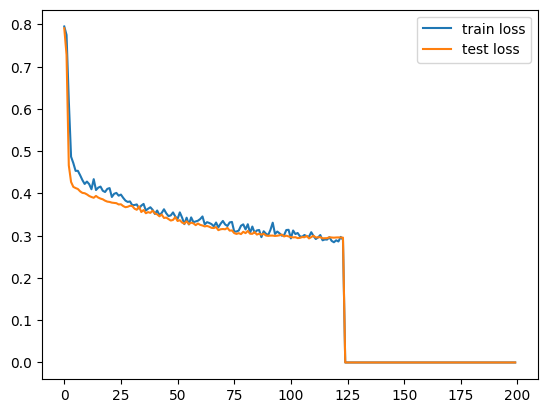

In [43]:
# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

## Evaluate Classification Performance

In [44]:
def confusion_matrix_from_predictions(targets: torch.Tensor, predictions: torch.Tensor) -> np.array:
    """
    Compute the confusion matrix from the model's predictions.
    
    Parameters
    ----------
    targets : torch.Tensor
        True binary labels (0 or 1).
    predictions : torch.Tensor
        Predicted binary labels (0 or 1).
    
    Returns
    -------
    np.array
        Confusion matrix as a 2x2 numpy array:
        [[TN, FP],
         [FN, TP]]
    """
    tp = ((predictions == 1) & (targets == 1)).sum().item()
    tn = ((predictions == 0) & (targets == 0)).sum().item()
    fp = ((predictions == 1) & (targets == 0)).sum().item()
    fn = ((predictions == 0) & (targets == 1)).sum().item()
    return np.array([[tn, fp], [fn, tp]])


@torch.no_grad()
def collect_confusion_matrix_from_batches(
    model: nn.Module, 
    loader: DataLoader, 
    threshold: Optional[float] = None, 
    temperature: Optional[float] = None
) -> np.array:
    """
    Collects the confusion matrix from the model's predictions on the given data loader.
    
    Parameters
    ----------
    model : nn.Module
        The trained model to evaluate.
    loader : DataLoader
        DataLoader providing the evaluation data.
    threshold : float, default=0.5
        Decision threshold for classifying positive vs negative.
    temperature : float, default=1.0
        Temperature scaling factor applied to logits before computing probabilities.
        
    Returns
    -------
    np.array
        Confusion matrix as a 2x2 numpy array:
        [[TN, FP],
         [FN, TP]]
    """
    model.eval()
    cm = np.zeros((2, 2), dtype=int)
            
    temperature = getattr(model, 'temperature', torch.tensor(1.0, device=device)) if temperature is None else temperature
    if isinstance(temperature, float):
        temperature = torch.tensor(temperature, device=device)

    threshold = getattr(model, 'threshold', torch.tensor(0.5, device=device)) if threshold is None else threshold
    if isinstance(threshold, float):
        threshold = torch.tensor(threshold, device=device)

    for inputs, targets in loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)

        logits = model(inputs)#.squeeze(1)
        logits /= temperature.clamp(min=1e-6)

        # Compute probabilities and predictions
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= threshold).long()

        # Update confusion counts
        cm += confusion_matrix_from_predictions(targets, predictions)
        
    # Confusion matrix
    return cm

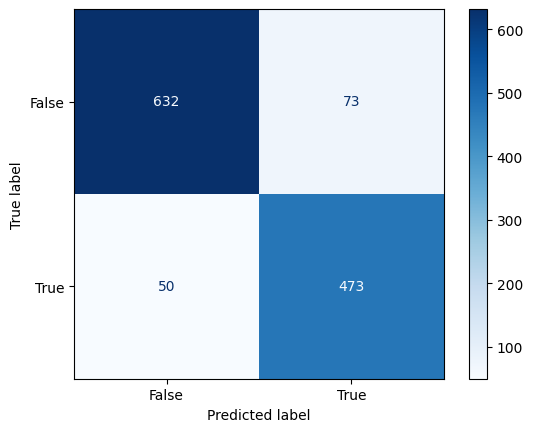

In [45]:
cm = collect_confusion_matrix_from_batches(model, test_loader)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
disp.plot(cmap='Blues')

## Calibrate Model Outputs with Temperature Scaling

When a model is trained for binary classification, it isn't trained to output calibrated probabilities - it's trained to separate classes and to minimize a loss. That is, the model learns weights that minimize classification error on log-loss. It focuses on ranking samples correctly, not making the probabilities numerically accurate. There is no penalty for being overconfident, as long as the predictions are correct. So the model often outputs probabilities like 0.99 for positives and 0.01 for negatives - even when it’s not that certain. That’s great for accuracy, but poor for calibration. When we do calibration, we want to choose a better probability treshold. For being able to do that, we need a model that outputs accurate (calibrated) probabilities. Temperature scaling achieves this by rescaling the outputs of the model.

    logits -> logits / T

- T = 1 → no change  
- T > 1 → softer (less confident) probabilities  
- T < 1 → sharper (more confident) probabilities  

This makes predicted probabilities **well-calibrated**, meaning that a prediction of 0.8 truly reflects about 80% likelihood. This enables us to choose a good probability treshold for classifying negatives, and thus increase the NPV of the model.

In [46]:
class TemperatureScaler(nn.Module):
    """
    Single-parameter temperature scaling module for binary classification logits.

    This module applies a learnable scalar temperature `T` to rescale model logits
    before applying the sigmoid function. Temperature scaling is a post-hoc
    calibration technique that adjusts model confidence without changing class
    predictions.

    The transformation is defined as:

        logits_scaled = logits / T

    where `T` > 0 is optimized on a validation set to minimize
    binary cross-entropy (negative log-likelihood). Larger values of `T` produce
    softer (less confident) probabilities, while smaller values sharpen them.

    Parameters
    ----------
    None
        The module initializes with a single learnable parameter `temperature`,
        set to 1.0 by default.

    Attributes
    ----------
    temperature : torch.nn.Parameter of shape (1,)
        Learnable scalar parameter representing the temperature. It is optimized
        during calibration (typically using `LBFGS`) and constrained to remain
        positive using `clamp(min=1e-6)` in the forward pass.

    Notes
    -----
    - Temperature scaling is a **calibration** step, not a retraining step.
      The base model weights remain fixed.
    - Commonly used after training a classifier to make its predicted probabilities
      better match the observed frequencies of the true labels.
    - For multi-class classification, the same concept can be extended by dividing
      the softmax logits by the same scalar `T`.

    Examples
    --------
    >>> import torch
    >>> logits = torch.tensor([[2.0], [0.0], [-2.0]])
    >>> scaler = TemperatureScaler()
    >>> scaler.temperature.data.fill_(2.0)  # set T = 2 manually
    >>> logits_scaled = scaler(logits)
    >>> logits_scaled
    tensor([[ 1.0000],
            [ 0.0000],
            [-1.0000]])
    >>> probs = torch.sigmoid(logits_scaled)
    >>> probs
    tensor([[0.7311],
            [0.5000],
            [0.2689]])
    """

    def __init__(self):
        super().__init__()
        # Initialize temperature parameter to 1.0 (no scaling initially)
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        """
        Apply temperature scaling to input logits.

        Parameters
        ----------
        logits : torch.Tensor
            Raw, unnormalized model outputs (logits), typically of shape (N,) or (N, 1).

        Returns
        -------
        torch.Tensor
            Logits rescaled by the current temperature value:
            logits_scaled = logits / (temperature + 1e-6)
        """
        return logits / self.temperature.clamp(min=1e-6)



def find_optimal_temperature(model: nn.Module, loader: DataLoader) -> "TemperatureScaler":
    """
    Fit a temperature scaling parameter on a validation set for model calibration.

    This function learns a single scalar temperature `T` that rescales the model's
    logits to produce better-calibrated probabilities. The temperature is optimized
    by minimizing binary cross-entropy (BCE) loss on a held-out validation set,
    keeping the base model's weights frozen.

    The learned `TemperatureScaler` can then be applied during inference to adjust
    model confidence via:
        logits_scaled = logits / T
        probs = sigmoid(logits_scaled)

    Parameters
    ----------
    model : torch.nn.Module
        Trained classification model that outputs raw logits (not probabilities).
        Its parameters remain frozen during temperature fitting.
    loader : torch.utils.data.DataLoader
        DataLoader for the validation dataset used to fit the temperature.
        Should yield batches of `(inputs, targets)` where `targets` are binary labels (0 or 1).
    device : torch.device
        Device on which to perform computation (e.g., `torch.device("cuda")`).

    Returns
    -------
    TemperatureScaler
        A fitted instance of `TemperatureScaler` with a single learned parameter `temperature`.
        This object can be applied to logits to obtain calibrated probabilities.

    Notes
    -----
    - The optimization uses the L-BFGS algorithm (`torch.optim.LBFGS`) because it performs
      an internal line search and typically converges in one call for a 1D parameter like `T`.
    - The loss minimized is the negative log-likelihood (BCE), which measures
      calibration quality of predicted probabilities.
    - After fitting, the model's accuracy or AUC will remain unchanged, but its
      predicted probabilities will better reflect true likelihoods.
    - Typical learned temperature values are `T > 1`, indicating that the model
      was initially overconfident.

    Examples
    --------
    >>> model.eval()
    >>> scaler = fit_temperature_on_val(model, val_loader, device)
    >>> T = scaler.temperature.item()
    >>> print(f"Learned temperature: {T:.3f}")
    >>> # Apply to new logits
    >>> with torch.no_grad():
    ...     logits = model(xb)
    ...     logits_scaled = logits / T
    ...     probs = torch.sigmoid(logits_scaled)
    """
    
    device = next(model.parameters()).device

    # Put model in evaluation mode
    model.eval()

    # Collect all logits and labels from the validation loader
    logits_list, y_list = [], []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            logits_list.append(model(inputs).detach())
            y_list.append(targets.to(device).float())

    # Concatenate validation data into single tensors
    logits = torch.cat(logits_list).to(device)
    y = torch.cat(y_list).to(device)

    # Create a learnable temperature scaler (1 parameter)
    scaler = TemperatureScaler().to(device)
    criterion = nn.BCEWithLogitsLoss()

    # Use L-BFGS optimizer for efficient scalar optimization
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.1, max_iter=50)

    # Define closure for L-BFGS: computes loss and gradients
    def closure():
        optimizer.zero_grad()
        loss = criterion(scaler(logits), y)
        loss.backward()
        return loss

    # Fit temperature by running a single optimizer step (LBFGS will iterate internally)
    scaler.train()
    optimizer.step(closure)
    scaler.eval()
    
    temperature = scaler.temperature.detach().cpu().item()

    return temperature

In [47]:
temperature = find_optimal_temperature(model, test_loader)
print(f"[Calibration] learned temperature T = {temperature:.4f}")

[Calibration] learned temperature T = 1.0184


In [48]:
class CalibratedModel(nn.Module):
    """
    Wraps a base model and applies temperature scaling to its logits.
    If return_probs=True, returns calibrated probabilities.
    Otherwise returns calibrated logits (for BCEWithLogitsLoss).
    """
    def __init__(self, base_model: nn.Module, temperature: float = 1.0):
        super().__init__()
        self.model = base_model
        # store T as a non-trainable buffer; moves with .to(device) and saved in state_dict
        self.register_buffer("temperature", torch.tensor(float(temperature)))

    def forward(self, x):
        logits = self.model(x)#.squeeze(1)
        logits = logits / self.temperature.clamp(min=1e-6)
        return logits  # calibrated logits

In [49]:
model_calibrated = CalibratedModel(model, temperature=temperature)
model_calibrated.to(device)

CalibratedModel(
  (model): BaseModel(
    (norm): Standardize()
    (net): Sequential(
      (0): Linear(in_features=10, out_features=10, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=10, out_features=10, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=10, out_features=10, bias=True)
      (7): ReLU()
      (8): Dropout(p=0.1, inplace=False)
      (9): Linear(in_features=10, out_features=10, bias=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
      (12): Linear(in_features=10, out_features=10, bias=True)
      (13): ReLU()
      (14): Dropout(p=0.1, inplace=False)
      (15): Linear(in_features=10, out_features=1, bias=True)
    )
  )
)

## Threshold Sweep to maximize NPV

In [50]:
@torch.no_grad()
def collect_logits_and_targets(model: nn.Module, loader: DataLoader, temperature: float = 1.0) -> tuple[torch.Tensor, torch.Tensor]:
    device = next(model.parameters()).device
    model.eval()
    
    logits_list, targets_list = [], []
    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        logits = model(inputs)
        
        logits_list.append(logits)
        targets_list.append(targets)

    logits = torch.cat(logits_list) / temperature
    targets = torch.cat(targets_list).long()

    return logits, targets


def scorer(cm: np.ndarray) -> float:
    metrics = calculate_performance_metrics(cm)
    score = 0.8 * metrics['NPV'] + 0.2 * metrics['PPV']
    return score


def find_optimal_threshold(model: nn.Module, loader: DataLoader, temperature: float = 1.0) -> float:
    
    model.eval()
    
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t, best_score = 0.5, -1.0

    logits, targets = collect_logits_and_targets(model, loader, temperature=temperature)
    probabilities = torch.sigmoid(logits)

    for t in thresholds:
        predictions = (probabilities >= t).long()
        cm = confusion_matrix_from_predictions(targets, predictions)
        score = scorer(cm)
        if score > best_score:
            best_score, best_t = score, t

    return best_t

In [51]:
threshold = find_optimal_threshold(model_calibrated, test_loader)
print(f"[Threshold] optimal threshold = {threshold:.3f}")

[Threshold] optimal threshold = 0.320


In [52]:
class Classifier(nn.Module):
    """
    Wraps a base model and applies temperature scaling and tresholding to its logits.
    If return_probs=True, returns calibrated and tuned probabilities.
    Otherwise returns calibrated logits (for BCEWithLogitsLoss).
    """
    def __init__(self, base_model: nn.Module, threshold: float=1.0, return_probs: bool = True):
        super().__init__()
        self.model = base_model
        self.return_probs = return_probs
        
        # store threshold as a non-trainable buffer; moves with .to(device) and saved in state_dict
        self.register_buffer("threshold", torch.tensor(float(threshold)))
        
    @property
    def temperature(self) -> torch.Tensor:
        return self.model.temperature

    def forward(self, x):
        logits = self.model(x)  # calibrated logits
        if self.return_probs:
            probs = torch.sigmoid(logits)
            preds = (probs >= self.threshold).long()
            return preds        # 0/1
        return logits           # calibrated logits
    

classifier = Classifier(model_calibrated, threshold=threshold, return_probs=False)
classifier.to(device)

Classifier(
  (model): CalibratedModel(
    (model): BaseModel(
      (norm): Standardize()
      (net): Sequential(
        (0): Linear(in_features=10, out_features=10, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=10, out_features=10, bias=True)
        (4): ReLU()
        (5): Dropout(p=0.1, inplace=False)
        (6): Linear(in_features=10, out_features=10, bias=True)
        (7): ReLU()
        (8): Dropout(p=0.1, inplace=False)
        (9): Linear(in_features=10, out_features=10, bias=True)
        (10): ReLU()
        (11): Dropout(p=0.1, inplace=False)
        (12): Linear(in_features=10, out_features=10, bias=True)
        (13): ReLU()
        (14): Dropout(p=0.1, inplace=False)
        (15): Linear(in_features=10, out_features=1, bias=True)
      )
    )
  )
)

## Evaulate Classification Performance

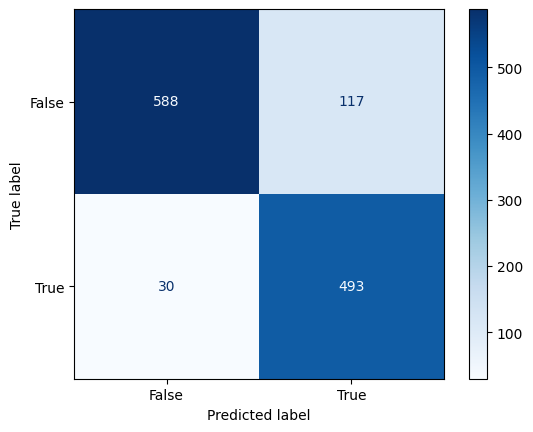

In [53]:
cm = collect_confusion_matrix_from_batches(classifier, test_loader)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
disp.plot(cmap='Blues')

## Save model

In [54]:
scripted = torch.jit.script(classifier.eval())
scripted.save(model_file_path)

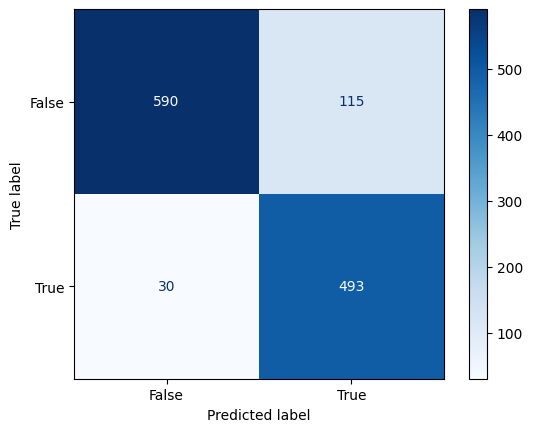

In [55]:
# test if model works after being reloaded
loaded = torch.jit.load(model_file_path, map_location=device)
loaded.eval()

cm = collect_confusion_matrix_from_batches(loaded, test_loader)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
disp.plot(cmap='Blues')